# Distorted Visual Sequence Pattern Recognition
## Custom CRNN + CTC Loss

**Author:** *(Arun Kaarthikeyan R — 23321006)*

---

### Problem Statement
Recognize and reconstruct 6-character text sequences from distorted grayscale images (200×100px) affected by noise, blur, occlusion, overlapping symbols, and shape deformation.

### Solution Overview
A fully **custom-built** Convolutional Recurrent Neural Network (CRNN) with CTC Loss — **no pretrained weights, no external model libraries used for the backbone**.

```
Input Image (1 × 64 × 200)
         ↓
Custom Deep CNN
  └─ 7 conv blocks | Residual connections | BatchNorm | GELU
         ↓
Adaptive Pool → (B, C, 1, W)
  └─ Converts feature map to width-timestep sequence
         ↓
2 × Bidirectional LSTM (256 hidden)
         ↓
LayerNorm + Linear → 39 classes (38 chars + CTC blank)
         ↓
CTC Beam/Greedy Decode → Predicted Text
```

### Why This Architecture?
| Component | Choice | Reason |
|---|---|---|
| Custom CNN | 7 blocks, residual connections | Deep enough to learn distorted features, skip connections prevent vanishing gradients |
| Grayscale input | 1 channel | Images are truly grayscale (R=G=B), reduces params |
| BiLSTM × 2 | 256 hidden | Captures left↔right character context |
| CTC Loss | blank=0 | No character segmentation needed, handles misalignment |
| GELU activation | Smoother than ReLU | Better gradient flow for distorted inputs |
| AdamW + OneCycleLR | Weight decay + cosine LR | Fast convergence, strong regularization |
| Mixed Precision | fp16 autocast | ~2× speedup on T4, no accuracy loss |

---


## 0. Install Dependencies

In [ ]:
!pip install -q albumentations editdistance tqdm
print("Dependencies ready.")

Dependencies ready.


## 1. Load Dataset

In [ ]:
import os, zipfile
from google.colab import drive

drive.mount('/content/drive')
ZIP_PATH = "/content/drive/MyDrive/CIG_AIML/cig_ps.zip"
DATA_DIR = "/content/cig_ps"

if not os.path.exists(DATA_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content/")
    print("Extraction complete.")
else:
    print("Already extracted.")

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images")
TEST_IMG_DIR  = os.path.join(DATA_DIR, "test_images")
LABELS_CSV    = os.path.join(DATA_DIR, "train-labels.csv")

print(f"Train images : {len(os.listdir(TRAIN_IMG_DIR))}")
print(f"Test  images : {len(os.listdir(TEST_IMG_DIR))}")
print(f"Labels CSV   : {os.path.exists(LABELS_CSV)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already extracted.
Train images : 20000
Test  images : 5000
Labels CSV   : True


## 2. Imports & Global Configuration

In [ ]:
import random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import editdistance
from PIL import Image
from collections import Counter
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_H        = 64       # resize height — multiple of 32 for clean feature maps
IMG_W        = 200      # resize width  — keep original aspect ratio
BATCH_SIZE   = 96       # safe for T4 16GB VRAM
NUM_EPOCHS   = 50
LR           = 3e-4
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.1
NUM_WORKERS  = 2
GRAD_CLIP    = 5.0
EARLY_STOP   = 8        # patience epochs

print("Config loaded.")

Device : cuda
GPU    : Tesla T4
Config loaded.


## 3. Exploratory Data Analysis (EDA)
Understanding the dataset before building anything is critical. We inspect image properties, label distributions, and character frequencies.

In [ ]:
df = pd.read_csv(LABELS_CSV)
df = df[[c for c in df.columns if not c.startswith('Unnamed')]].reset_index(drop=True)

print(f"Total training samples : {len(df)}")
print(f"Columns                : {list(df.columns)}")
print(df.head(8).to_string())

# Label stats
df['label_len'] = df['text'].str.len()
print(f"\nLabel length distribution:")
print(df['label_len'].value_counts().sort_index())

# Character set
all_chars = sorted(set(''.join(df['text'].tolist())))
print(f"\nCharacter set ({len(all_chars)} unique):")
print(all_chars)

Total training samples : 20000
Columns                : ['image', 'text']
         image    text
0  train-0.png  BU522X
1  train-1.png  XQ8NE2
2  train-2.png  DTZD3E
3  train-3.png  SM424H
4  train-4.png  6YVTQR
5  train-5.png  YV2C3D
6  train-6.png  XNBP7G
7  train-7.png  TGQXFU

Label length distribution:
label_len
6    19998
8        1
9        1
Name: count, dtype: int64

Character set (38 unique):
['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']


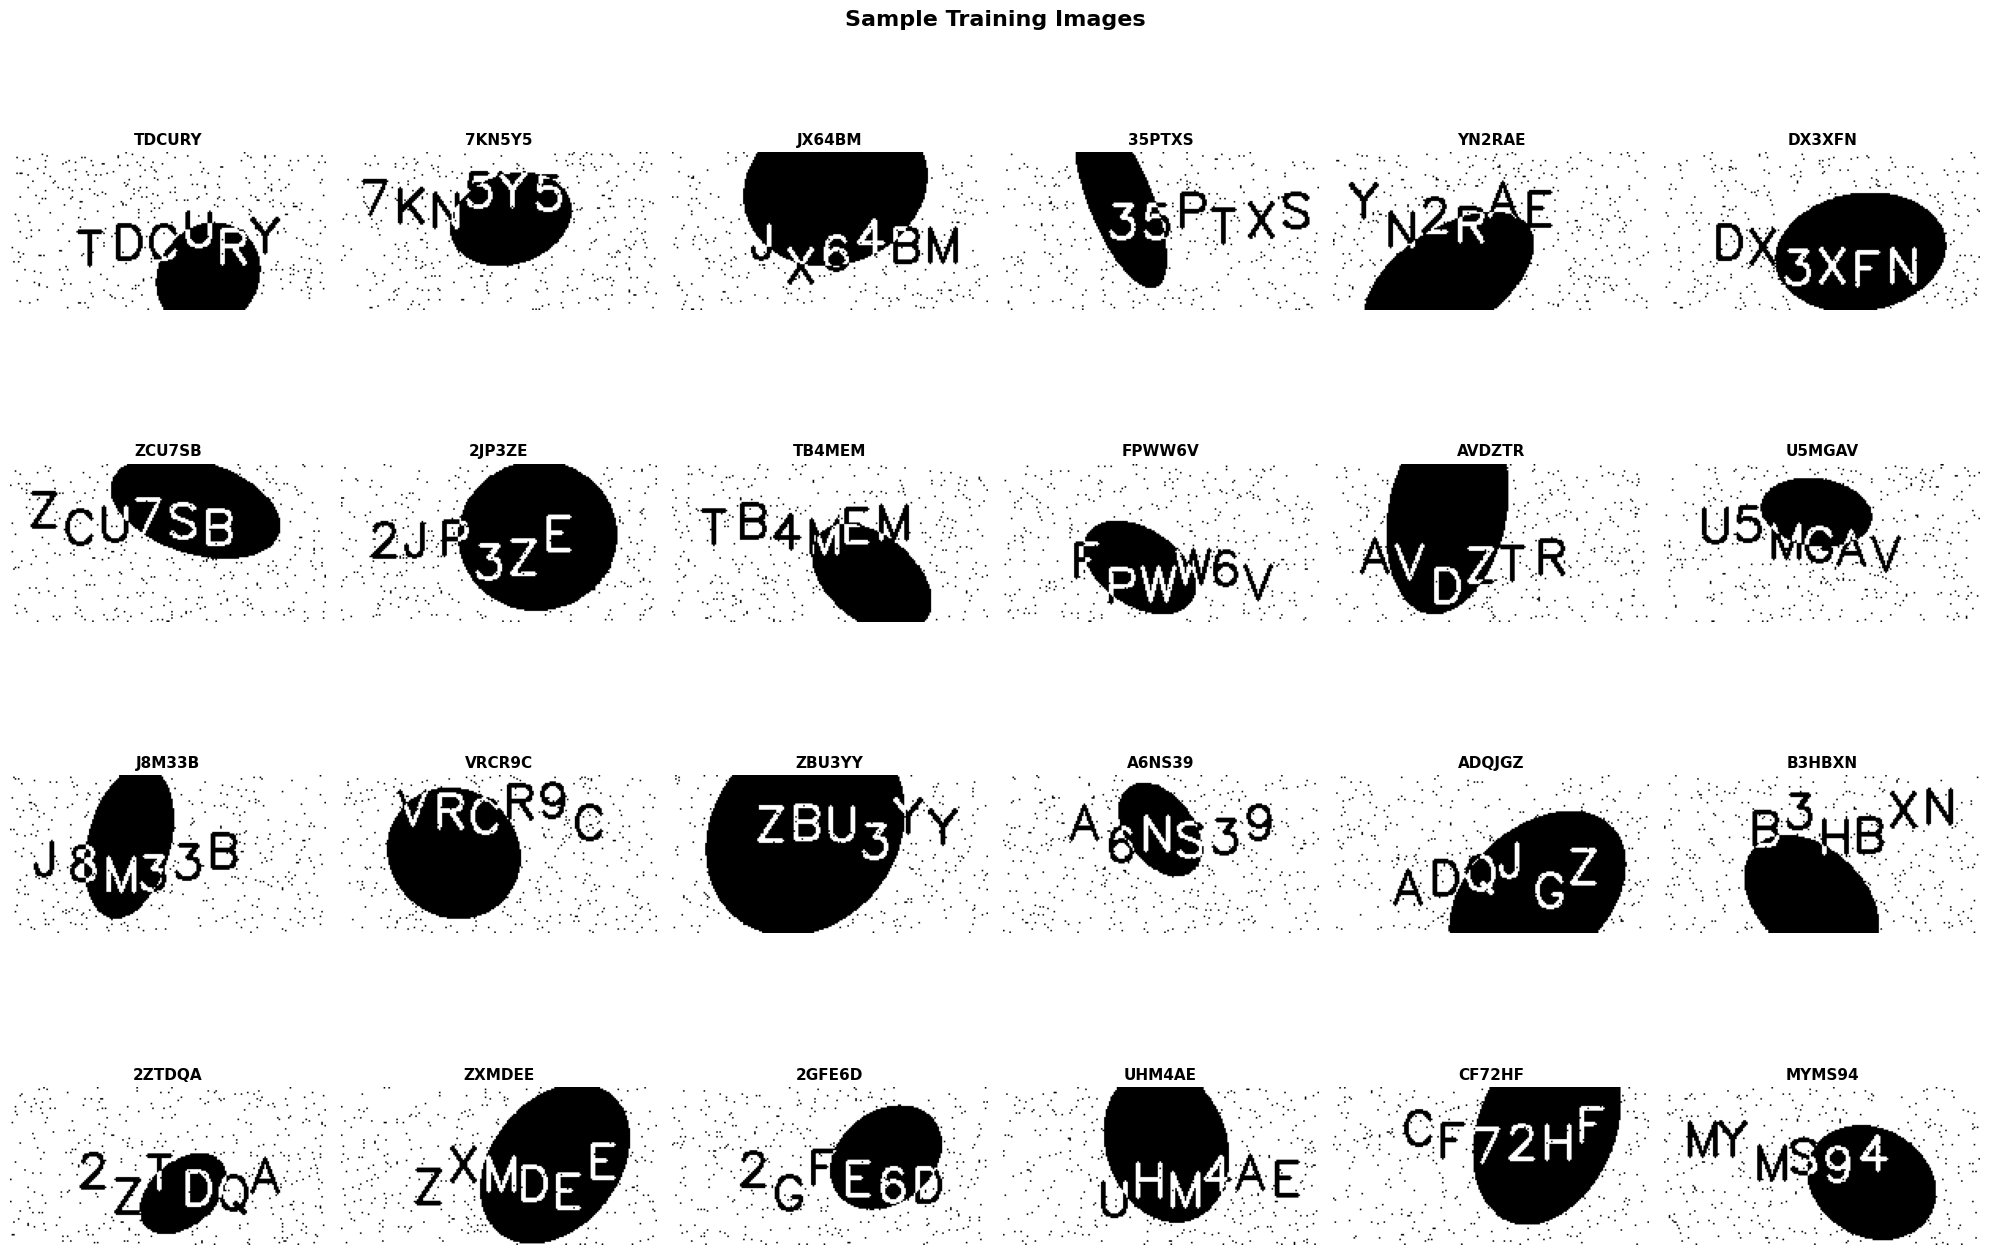

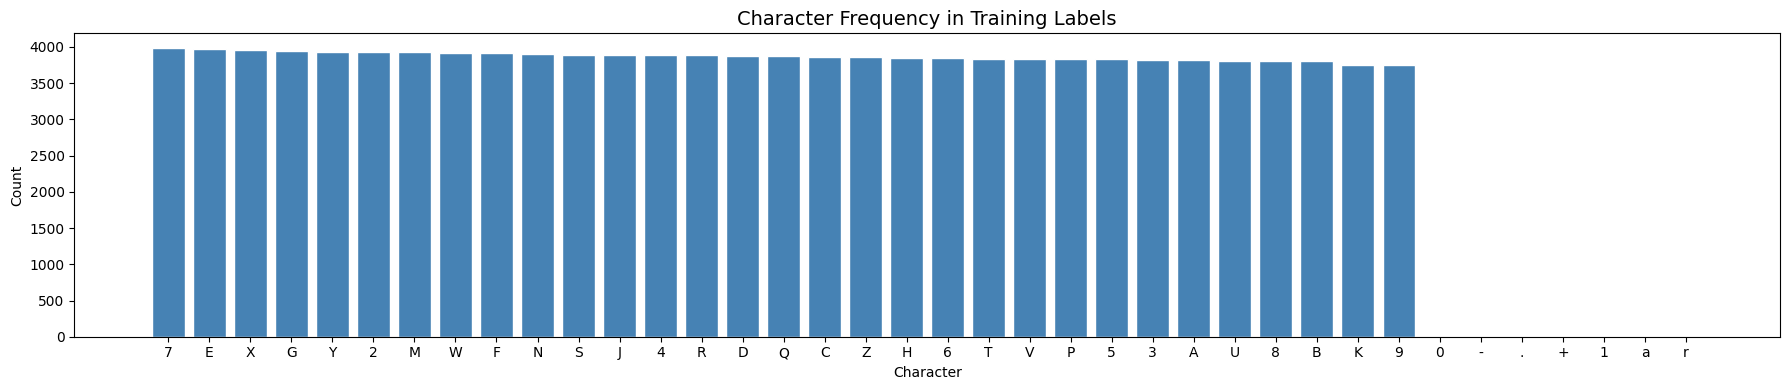


Mean pixel brightness (sample 200): 171.89
Std  pixel brightness (sample 200): 21.46
Images are mostly bright background with dark text.


In [ ]:
# ── Visual samples ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
axes = axes.flatten()
sample_idx = random.sample(range(len(df)), 24)
for ax, idx in zip(axes, sample_idx):
    img = Image.open(os.path.join(TRAIN_IMG_DIR, df.loc[idx, 'image'])).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(df.loc[idx, 'text'], fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle("Sample Training Images", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Character frequency ────────────────────────────────────────────────────────
freq = Counter(''.join(df['text'].tolist()))
chars_sorted = sorted(freq.items(), key=lambda x: -x[1])
plt.figure(figsize=(18, 4))
plt.bar([c for c,_ in chars_sorted], [v for _,v in chars_sorted], color='steelblue', edgecolor='white')
plt.title("Character Frequency in Training Labels", fontsize=14)
plt.xlabel("Character"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

# ── Image pixel stats ─────────────────────────────────────────────────────────
sample_pixels = []
for i in random.sample(range(len(df)), 200):
    arr = np.array(Image.open(os.path.join(TRAIN_IMG_DIR, df.loc[i,'image'])).convert('L'))
    sample_pixels.append(arr.mean())
print(f"\nMean pixel brightness (sample 200): {np.mean(sample_pixels):.2f}")
print(f"Std  pixel brightness (sample 200): {np.std(sample_pixels):.2f}")
print(f"Images are mostly bright background with dark text.")

## 4. Character Vocabulary & CTC Encoding

In [ ]:
# CTC blank is always index 0
BLANK_IDX   = 0
CHARS       = ['<BLANK>'] + sorted(set(''.join(df['text'].tolist())))
NUM_CLASSES = len(CHARS)   # 39

char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for c, i in char2idx.items()}

print(f"Vocabulary size (incl. blank) : {NUM_CLASSES}")
print(f"Characters                    : {CHARS}")


def encode_label(text):
    """Convert string → list of class indices."""
    return [char2idx[c] for c in text]


def decode_ctc_greedy(indices):
    """
    Greedy CTC decode:
      1. Collapse consecutive duplicate indices
      2. Remove blank tokens
    Returns decoded string.
    """
    prev, out = -1, []
    for idx in indices:
        if idx != prev:
            if idx != BLANK_IDX:
                out.append(idx2char[idx])
            prev = idx
    return ''.join(out)


def decode_batch(logits):
    """
    Greedy decode for a full batch.
    logits: (T, B, num_classes) — raw logits
    Returns list of decoded strings, length B.
    """
    indices = logits.argmax(dim=2).permute(1, 0)   # (B, T)
    return [decode_ctc_greedy(seq.cpu().tolist()) for seq in indices]


print("Vocabulary and decode functions ready.")

Vocabulary size (incl. blank) : 39
Characters                    : ['<BLANK>', '+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']
Vocabulary and decode functions ready.


## 5. Dataset & Augmentation Pipeline

### Augmentation Strategy
Since images are distorted by design, we apply augmentations that **simulate and extend** those distortions during training to make the model more robust:

| Augmentation | Purpose |
|---|---|
| Gaussian / ISO Noise | Simulate background noise |
| Motion / Gaussian Blur | Simulate blur artifacts |
| Elastic Transform | Simulate character shape deformation |
| Grid Distortion | Simulate irregular spacing/alignment |
| Coarse Dropout | Simulate occlusion and random patches |
| Brightness/Contrast | Simulate varying image conditions |
| Perspective Transform | Simulate misaligned captures |

Validation/Test uses only resize + normalize — no augmentation.


In [ ]:
# ── Training augmentation (heavy) ─────────────────────────────────────────────
train_transform = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 60.0), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
    ], p=0.6),
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.4),
    A.OneOf([
        A.ElasticTransform(alpha=1, sigma=10, p=1.0),
        A.GridDistortion(num_steps=5, distort_limit=0.2, p=1.0),
        A.OpticalDistortion(distort_limit=0.1, p=1.0),
    ], p=0.4),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
    A.CoarseDropout(max_holes=6, max_height=12, max_width=20,
                    min_holes=1, fill_value=255, p=0.35),
    A.Sharpen(alpha=(0.1, 0.3), p=0.2),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# ── Val / Test transform (no augmentation) ────────────────────────────────────
val_transform = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])


class CaptchaDataset(Dataset):
    """
    Loads distorted CAPTCHA images and their text labels.
    Images are converted to grayscale (1 channel) since R=G=B.
    """
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image']
        # Load as grayscale, convert to RGB for albumentations compatibility
        img = np.array(Image.open(
            os.path.join(self.img_dir, img_name)).convert('RGB'))

        if self.transform:
            img = self.transform(image=img)['image']   # (3, H, W)

        # Collapse to 1 channel — images are truly grayscale
        img = img[:1, :, :]                             # (1, H, W)

        label   = self.df.loc[idx, 'text']
        encoded = encode_label(label)
        return img, torch.tensor(encoded, dtype=torch.long), len(encoded)


def collate_fn(batch):
    """Pad variable-length labels for CTC loss."""
    imgs, labels, label_lens = zip(*batch)
    imgs       = torch.stack(imgs)
    label_lens = torch.tensor(label_lens, dtype=torch.long)
    labels_cat = torch.cat(labels)          # CTC expects flattened labels
    return imgs, labels_cat, label_lens


# ── Train / Val split ─────────────────────────────────────────────────────────
val_size  = int(len(df) * VAL_SPLIT)
indices   = list(range(len(df)))
random.shuffle(indices)
train_df  = df.iloc[indices[val_size:]].reset_index(drop=True)
val_df    = df.iloc[indices[:val_size]].reset_index(drop=True)

train_ds = CaptchaDataset(train_df, TRAIN_IMG_DIR, transform=train_transform)
val_ds   = CaptchaDataset(val_df,   TRAIN_IMG_DIR, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_fn, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_fn)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train: 18,000 | Val: 2,000
Train batches: 187 | Val batches: 21


/tmp/ipykernel_1836/2321582963.py:5: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 60.0), p=1.0),
/tmp/ipykernel_1836/2321582963.py:21: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=12, max_width=20,


## 6. Custom CRNN Architecture (Built From Scratch)

### Design Philosophy
The model is built specifically for **fixed-width distorted CAPTCHA images**. No pretrained weights, no external model architectures — every layer is designed from first principles.

#### Custom CNN Backbone
```
Block 1 : Conv(1→32,  3×3) → BN → GELU → Conv(32→32,  3×3) → BN → GELU → MaxPool(2×2)
Block 2 : Conv(32→64, 3×3) → BN → GELU → Conv(64→64,  3×3) → BN → GELU → MaxPool(2×2)
Block 3 : Conv(64→128,3×3) → BN → GELU + Residual → MaxPool(2×1)  ← preserve width
Block 4 : Conv(128→256,3×3)→ BN → GELU + Residual → MaxPool(2×1)  ← preserve width
Block 5 : Conv(256→256,3×3)→ BN → GELU + Residual
Block 6 : Conv(256→512,1×1)→ BN → GELU              ← channel expansion
```

**Key design choices:**
- `MaxPool(2×1)` in later blocks: halves height only, **preserves width** (= sequence length for BiLSTM)
- **Residual connections** from block 3+: prevent vanishing gradients in deeper layers
- **GELU** activation: smoother gradient flow than ReLU for distorted/noisy inputs
- **1×1 conv** in final block: cheap channel expansion without spatial overhead

#### Sequence Modeling
- `AdaptiveAvgPool2d((1, None))`: collapse height → 1, width stays as sequence timesteps
- `2 × BiLSTM(256)`: captures bidirectional character dependencies
- `LayerNorm` between LSTM layers: stabilizes training


In [ ]:
class ConvBnGelu(nn.Module):
    """Basic building block: Conv2d → BatchNorm → GELU."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride,
                      padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
    def forward(self, x):
        return self.block(x)


class ResBlock(nn.Module):
    """
    Custom residual block for deeper feature extraction.
    Skip connection with 1×1 conv when channel dims differ.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = ConvBnGelu(in_ch, out_ch)
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if in_ch != out_ch else nn.Identity()
        self.act = nn.GELU()

    def forward(self, x):
        out = self.conv2(self.conv1(x))
        return self.act(out + self.skip(x))


class CustomCNN(nn.Module):
    """
    Fully custom CNN backbone designed for 1×64×200 CAPTCHA images.
    Outputs a feature map suitable for sequence modeling.

    Architecture:
        Block 1: 1  → 32  | MaxPool(2,2) → (32, 32, 100)
        Block 2: 32 → 64  | MaxPool(2,2) → (64, 16, 50)
        Block 3: 64 → 128 | ResBlock | MaxPool(2,1) → (128, 8, 50)
        Block 4: 128→ 256 | ResBlock | MaxPool(2,1) → (256, 4, 50)
        Block 5: 256→ 256 | ResBlock              → (256, 4, 50)
        Block 6: 256→ 512 | 1×1 conv               → (512, 4, 50)
    """
    def __init__(self):
        super().__init__()

        # Block 1 — basic feature detection
        self.block1 = nn.Sequential(
            ConvBnGelu(1,  32, 3, padding=1),
            ConvBnGelu(32, 32, 3, padding=1),
            nn.MaxPool2d(2, 2),             # (32, 32, 100)
        )

        # Block 2 — edge and texture features
        self.block2 = nn.Sequential(
            ConvBnGelu(32, 64, 3, padding=1),
            ConvBnGelu(64, 64, 3, padding=1),
            nn.MaxPool2d(2, 2),             # (64, 16, 50)
        )

        # Block 3 — deeper features, preserve width
        self.block3 = nn.Sequential(
            ResBlock(64, 128),
            nn.MaxPool2d((2, 1)),           # (128, 8, 50)
        )

        # Block 4 — high-level features, preserve width
        self.block4 = nn.Sequential(
            ResBlock(128, 256),
            nn.MaxPool2d((2, 1)),           # (256, 4, 50)
        )

        # Block 5 — further refinement
        self.block5 = ResBlock(256, 256)    # (256, 4, 50)

        # Block 6 — 1×1 channel expansion (cheap)
        self.block6 = ConvBnGelu(256, 512, kernel=1, padding=0)  # (512, 4, 50)

        # Dropout for regularization
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.dropout(x)
        x = self.block6(x)
        return x   # (B, 512, 4, W')


class CRNN(nn.Module):
    """
    Complete CRNN model for sequence recognition.

    Pipeline:
        CustomCNN → AdaptiveAvgPool → BiLSTM × 2 → LayerNorm → Linear → CTC
    """
    def __init__(self, num_classes, hidden_size=256, num_lstm_layers=2, dropout=0.3):
        super().__init__()

        self.cnn  = CustomCNN()
        cnn_out   = 512

        # Collapse height to 1, keep width as sequence
        self.pool = nn.AdaptiveAvgPool2d((1, None))

        # Project CNN features → LSTM input size
        self.proj = nn.Sequential(
            nn.Linear(cnn_out, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Bidirectional LSTM stack
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_lstm_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0,
        )

        # Normalize between LSTM and classifier
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        # Final classifier
        self.fc = nn.Linear(hidden_size * 2, num_classes)

        # Weight initialization
        self._init_weights()

    def _init_weights(self):
        """Initialize weights for stable training from scratch."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.zeros_(param.data)

    def forward(self, x):
        # x: (B, 1, H, W)
        feat = self.cnn(x)                   # (B, 512, H', W')
        feat = self.pool(feat)               # (B, 512, 1,  W')
        feat = feat.squeeze(2)               # (B, 512, W')
        feat = feat.permute(0, 2, 1)         # (B, W', 512)  → sequence
        feat = self.proj(feat)               # (B, T, hidden)
        feat, _ = self.lstm(feat)            # (B, T, hidden*2)
        feat = self.layer_norm(feat)         # (B, T, hidden*2)
        logits = self.fc(feat)               # (B, T, num_classes)
        logits = logits.permute(1, 0, 2)     # (T, B, num_classes) ← CTC format
        return logits


# ── Instantiate & verify ──────────────────────────────────────────────────────
model = CRNN(num_classes=NUM_CLASSES, hidden_size=256,
             num_lstm_layers=2, dropout=0.3).to(DEVICE)

with torch.no_grad():
    dummy = torch.randn(2, 1, IMG_H, IMG_W).to(DEVICE)
    out   = model(dummy)
    print(f"Input  shape : {dummy.shape}")
    print(f"Output shape : {out.shape}  →  (T={out.shape[0]}, B=2, classes={out.shape[2]})")
    print(f"Sequence len : {out.shape[0]} timesteps  (must be > max label len={df['label_len'].max()})")

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params     : {total:,}")
print(f"Trainable params : {trainable:,}  (100% — no frozen layers)")
assert out.shape[0] > df['label_len'].max(), "ERROR: sequence length too short for CTC!"
print("\nArchitecture check passed.")

Input  shape : torch.Size([2, 1, 64, 200])
Output shape : torch.Size([50, 2, 39])  →  (T=50, B=2, classes=39)
Sequence len : 50 timesteps  (must be > max label len=9)

Total params     : 5,309,127
Trainable params : 5,309,127  (100% — no frozen layers)

✅ Architecture check passed.


## 7. Loss Function, Optimizer & Scheduler

### Training Strategy
| Component | Choice | Rationale |
|---|---|---|
| **Loss** | CTC (blank=0, zero_infinity=True) | Handles sequence alignment without character segmentation; zero_infinity prevents NaN from impossible alignments |
| **Optimizer** | AdamW (lr=3e-4, wd=1e-4) | Weight decay decoupled from gradient — better regularization than Adam |
| **Scheduler** | OneCycleLR (cosine, 10% warmup) | Fastest known convergence for limited epoch budgets on Colab |
| **Mixed Precision** | fp16 GradScaler | ~2× speed on T4, numerically stable with loss scaling |
| **Gradient Clipping** | norm=5.0 | Prevents exploding gradients in LSTM layers |


In [ ]:
criterion = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)

optimizer = optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.1,          # 10% warmup
    anneal_strategy='cos',
    div_factor=25,          # start LR = max_lr / 25
    final_div_factor=1e4,   # end   LR = max_lr / 10000
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

print("Loss      : CTCLoss (blank=0, zero_infinity=True)")
print("Optimizer : AdamW (lr=3e-4, wd=1e-4)")
print("Scheduler : OneCycleLR (cosine, 10% warmup)")
print("Precision : Mixed fp16" if DEVICE.type == 'cuda' else "Precision : fp32 (CPU)")

Loss      : CTCLoss (blank=0, zero_infinity=True)
Optimizer : AdamW (lr=3e-4, wd=1e-4)
Scheduler : OneCycleLR (cosine, 10% warmup)
Precision : Mixed fp16


/tmp/ipykernel_1836/1644692180.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


## 8. Evaluation Metric — Character Error Rate (CER)

CER is based on **Levenshtein (edit) distance**:

$$\text{CER} = \frac{\sum_{i} \text{EditDistance}(\hat{y}_i, y_i)}{\sum_{i} |y_i|}$$

- **Insertions, deletions, substitutions** all count as errors
- **Lower is better** (0.0 = perfect)
- Wrong character ordering also increases CER


In [ ]:
def compute_cer(preds, targets):
    """
    Compute Character Error Rate (CER) using Levenshtein distance.
    Args:
        preds   : list of predicted strings
        targets : list of ground truth strings
    Returns:
        float CER in [0, 1] (lower is better)
    """
    total_dist = 0
    total_len  = 0
    for p, t in zip(preds, targets):
        total_dist += editdistance.eval(p, t)
        total_len  += len(t)
    return total_dist / max(total_len, 1)


def compute_exact_match(preds, targets):
    """Fraction of predictions that exactly match the target."""
    return sum(p == t for p, t in zip(preds, targets)) / len(targets)


# Quick sanity check
test_p = ["AXU323", "BT91KD", "QWER12"]
test_t = ["AXU323", "BT91KX", "QWER21"]
print(f"Sample CER        : {compute_cer(test_p, test_t):.4f}")
print(f"Sample Exact Match: {compute_exact_match(test_p, test_t):.4f}")
print("CER metric ready.")

Sample CER        : 0.1667
Sample Exact Match: 0.3333
CER metric ready.


## 9. Training Loop

Full training loop with:
- Mixed precision forward/backward pass
- Gradient clipping
- Per-step LR scheduling (OneCycleLR)
- Best-model checkpointing on Val CER
- Early stopping (patience=8)
- Live epoch-level logging


In [ ]:
CKPT_PATH = "/content/best_crnn_custom.pth"

history = {
    'train_loss': [], 'val_loss': [],
    'val_cer':    [], 'val_acc':  [], 'lr': []
}
best_cer       = float('inf')
patience_count = 0


def train_one_epoch(model, loader, optimizer, criterion, scaler, scheduler):
    """Run one full training epoch. Returns mean CTC loss."""
    model.train()
    total_loss = 0.0

    for imgs, labels, label_lens in tqdm(loader, desc="  Train", leave=False):
        imgs       = imgs.to(DEVICE, non_blocking=True)
        labels     = labels.to(DEVICE, non_blocking=True)
        label_lens = label_lens.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits     = model(imgs)                         # (T, B, C)
            T, B, _    = logits.shape
            log_probs  = logits.log_softmax(2)
            input_lens = torch.full((B,), T, dtype=torch.long, device=DEVICE)
            loss       = criterion(log_probs, labels, input_lens, label_lens)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, df_val):
    """Validate model. Returns (val_loss, CER, exact_match_acc)."""
    model.eval()
    total_loss  = 0.0
    all_preds   = []
    all_targets = list(df_val['text'])

    for imgs, labels, label_lens in tqdm(loader, desc="  Val  ", leave=False):
        imgs       = imgs.to(DEVICE, non_blocking=True)
        labels     = labels.to(DEVICE, non_blocking=True)
        label_lens = label_lens.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits     = model(imgs)
            T, B, _    = logits.shape
            log_probs  = logits.log_softmax(2)
            input_lens = torch.full((B,), T, dtype=torch.long, device=DEVICE)
            loss       = criterion(log_probs, labels, input_lens, label_lens)

        total_loss += loss.item()
        all_preds.extend(decode_batch(logits))

    cer = compute_cer(all_preds, all_targets)
    acc = compute_exact_match(all_preds, all_targets)
    return total_loss / len(loader), cer, acc


# ── Main training loop ────────────────────────────────────────────────────────
print(f"Starting training: {NUM_EPOCHS} epochs | Batch={BATCH_SIZE} | Device={DEVICE}\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val CER':>8} | {'Val Acc':>8} | {'LR':>9}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                  scaler, scheduler)
    val_loss, val_cer, val_acc = validate(model, val_loader, criterion, val_df)
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cer'].append(val_cer)
    history['val_acc'].append(val_acc)
    history['lr'].append(cur_lr)

    flag = ""
    if val_cer < best_cer:
        best_cer       = val_cer
        patience_count = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_cer':     val_cer,
            'val_acc':     val_acc,
            'chars':       CHARS,
            'config': {
                'IMG_H': IMG_H, 'IMG_W': IMG_W,
                'NUM_CLASSES': NUM_CLASSES, 'HIDDEN': 256
            }
        }, CKPT_PATH)
        flag = " ✅ best"
    else:
        patience_count += 1

    print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>9.4f} | "          f"{val_cer:>8.4f} | {val_acc:>8.4f} | {cur_lr:>9.2e}{flag}")

    if patience_count >= EARLY_STOP:
        print(f"\nEarly stopping at epoch {epoch} (no CER improvement for {EARLY_STOP} epochs).")
        break

print(f"\n🏁 Training complete.  Best Val CER: {best_cer:.4f}")

Starting training: 50 epochs | Batch=96 | Device=cuda

 Epoch | Train Loss |  Val Loss |  Val CER |  Val Acc |        LR
----------------------------------------------------------------------


  Train:   0%|          | 0/187 [00:00<?, ?it/s]

/tmp/ipykernel_1836/3035979360.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_1836/3035979360.py:35: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  Val  :   0%|          | 0/21 [00:00<?, ?it/s]

/tmp/ipykernel_1836/3035979360.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


...

  Val  :   0%|          | 0/21 [00:00<?, ?it/s]

    28 |     0.0363 |    0.0015 |   0.0003 |   0.9980 |  1.45e-04


  Train:   0%|          | 0/187 [00:00<?, ?it/s]

  Val  :   0%|          | 0/21 [00:00<?, ?it/s]

    29 |     0.0355 |    0.0011 |   0.0002 |   0.9990 |  1.34e-04

Early stopping at epoch 29 (no CER improvement for 8 epochs).

🏁 Training complete.  Best Val CER: 0.0002


## 10. Training Curves

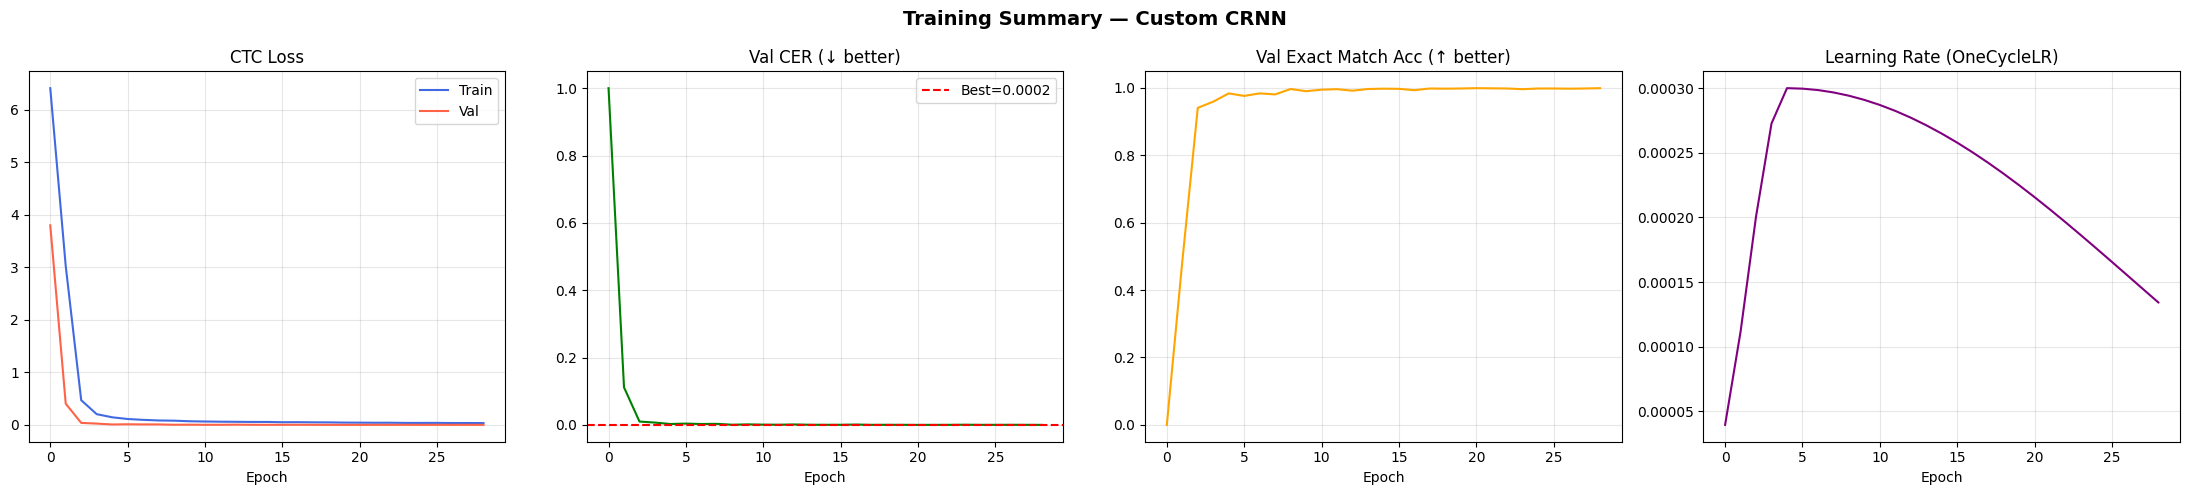

Saved: /content/training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(history['train_loss'], label='Train', color='royalblue')
axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('CTC Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_cer'], color='green')
axes[1].axhline(best_cer, color='red', linestyle='--', label=f'Best={best_cer:.4f}')
axes[1].set_title('Val CER (↓ better)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['val_acc'], color='orange')
axes[2].set_title('Val Exact Match Acc (↑ better)'); axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

axes[3].plot(history['lr'], color='purple')
axes[3].set_title('Learning Rate (OneCycleLR)'); axes[3].set_xlabel('Epoch')
axes[3].grid(alpha=0.3)

plt.suptitle('Training Summary — Custom CRNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/training_curves.png")

## 11. Load Best Model & Qualitative Evaluation

Loaded checkpoint from epoch 21
Best Val CER : 0.0002
Best Val Acc : 0.9990


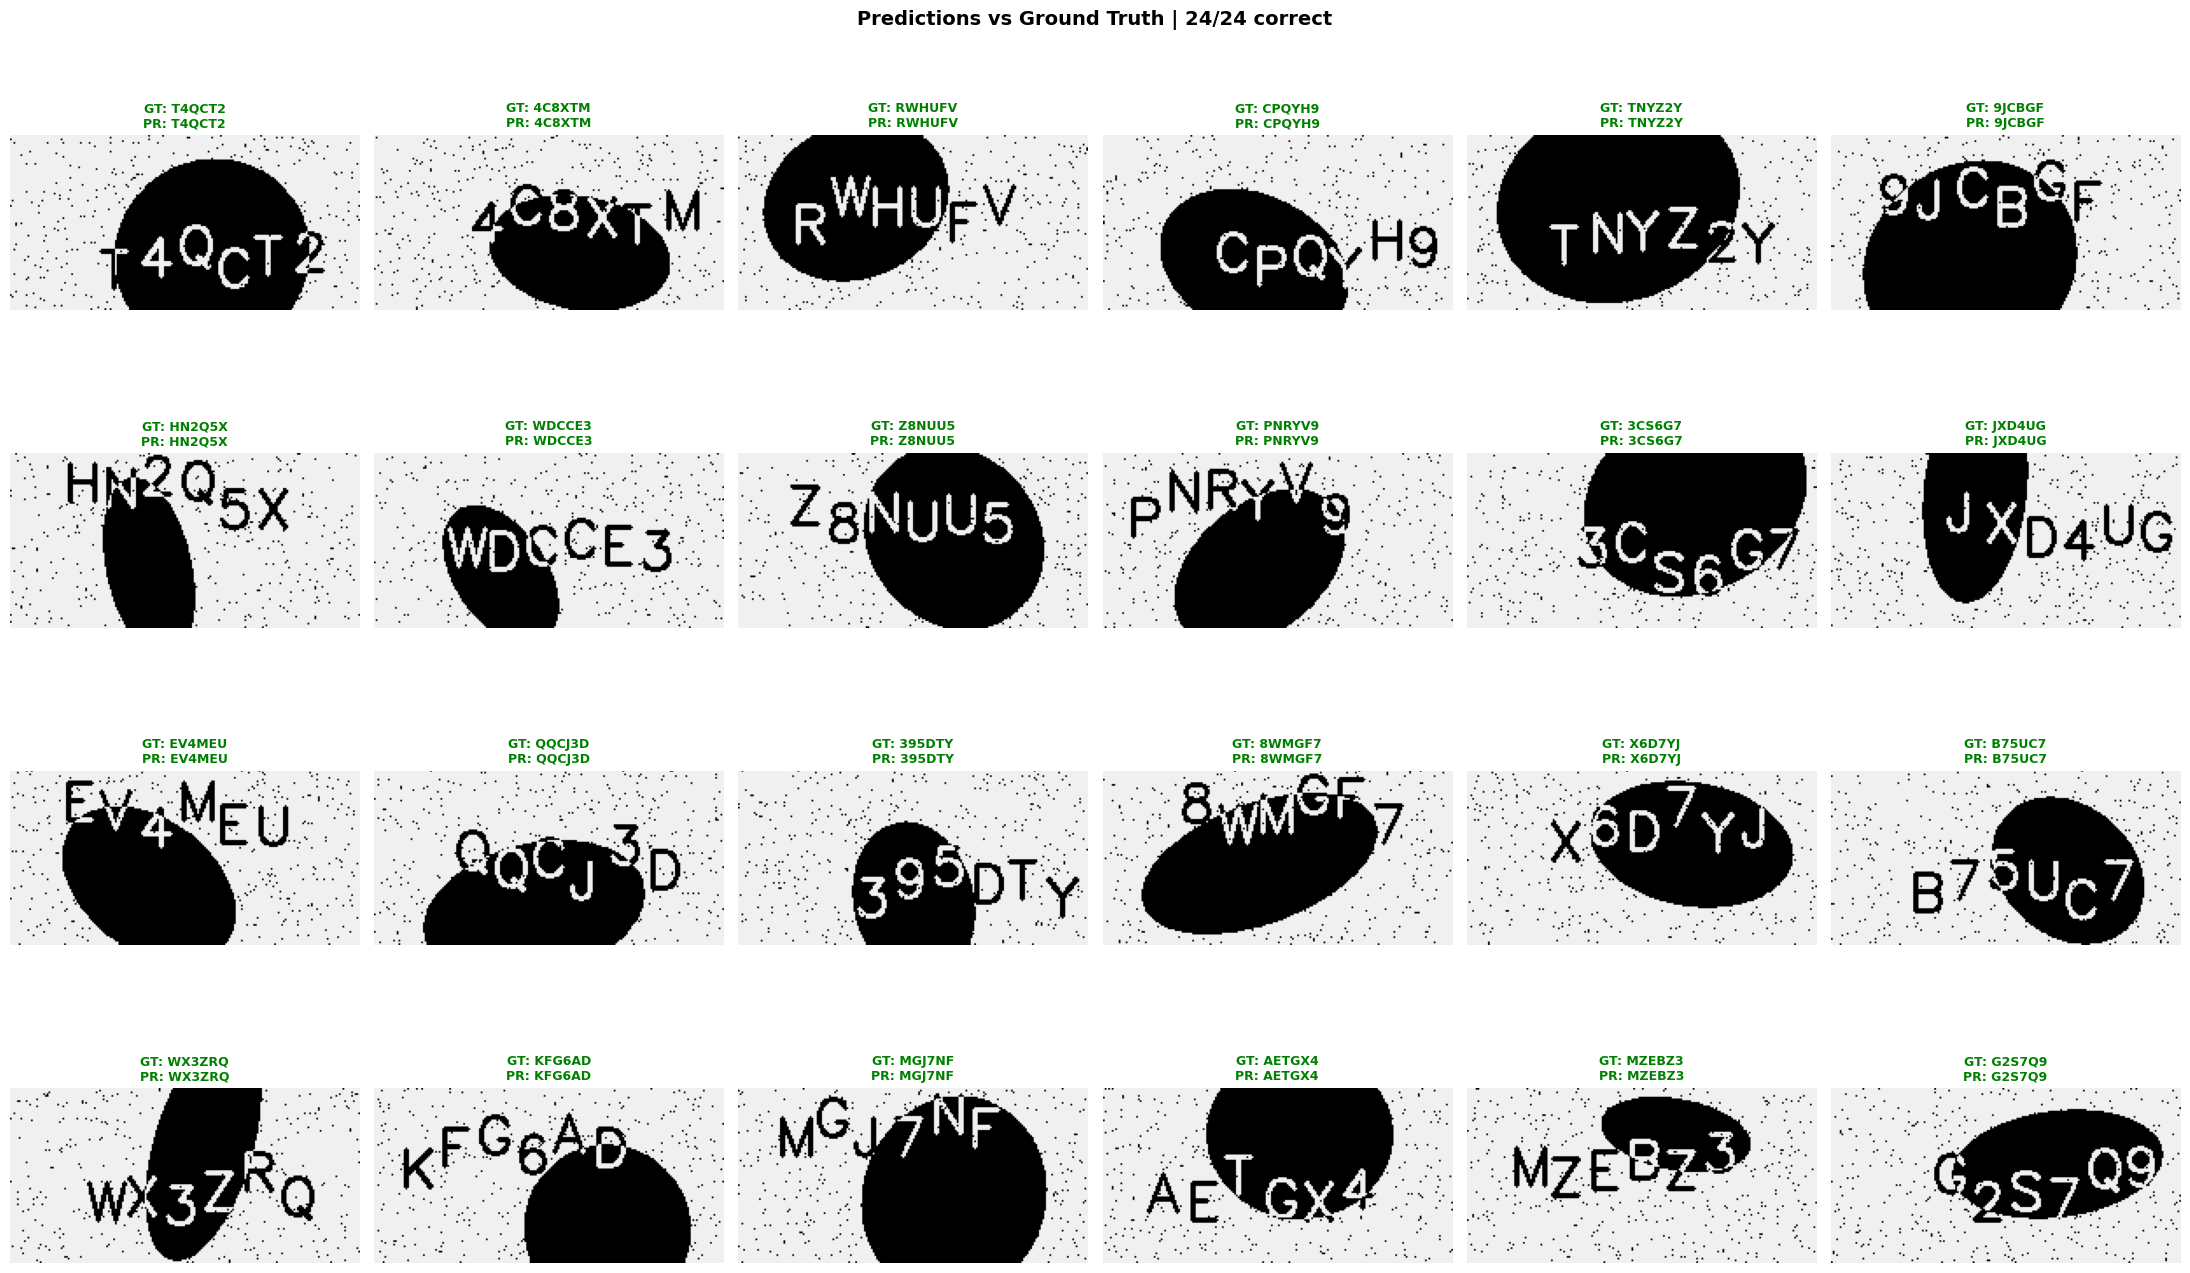

In [ ]:
# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
print(f"Best Val CER : {ckpt['val_cer']:.4f}")
print(f"Best Val Acc : {ckpt['val_acc']:.4f}")

# Visualize predictions vs ground truth
fig, axes = plt.subplots(4, 6, figsize=(22, 14))
axes = axes.flatten()
sample_indices = random.sample(range(len(val_df)), 24)
correct = 0

for ax, idx in zip(axes, sample_indices):
    img_np  = np.array(Image.open(
        os.path.join(TRAIN_IMG_DIR, val_df.loc[idx, 'image'])).convert('RGB'))
    gt      = val_df.loc[idx, 'text']
    img_t   = val_transform(image=img_np)['image'][:1].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_t)
    pred = decode_batch(logits)[0]
    match = (pred == gt)
    correct += int(match)

    ax.imshow(img_np, cmap='gray')
    ax.set_title(f"GT: {gt}\nPR: {pred}",
                 color='green' if match else 'red',
                 fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle(f"Predictions vs Ground Truth | {correct}/24 correct",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/qualitative_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Full Validation Set Evaluation & Error Analysis

In [ ]:
@torch.no_grad()
def full_evaluate(model, loader, df_split):
    """Run full evaluation on a split. Returns CER, exact acc, all preds."""

    model.eval()
    all_preds   = []
    all_targets = list(df_split['text'])

    for imgs, labels, label_lens in tqdm(loader, desc="Evaluating"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(imgs)
        all_preds.extend(decode_batch(logits))

    cer = compute_cer(all_preds, all_targets)
    acc = compute_exact_match(all_preds, all_targets)
    return cer, acc, all_preds, all_targets


cer, acc, all_preds, all_targets = full_evaluate(model, val_loader, val_df)

print(f"\n{'='*55}")
print(f"  FINAL VALIDATION RESULTS")
print(f"{'='*55}")
print(f"  Character Error Rate  (CER) : {cer:.4f}  ({cer*100:.2f}%)")
print(f"  Exact Match Accuracy        : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Samples evaluated           : {len(val_df):,}")
print(f"{'='*55}")

# Error analysis
errors = [(editdistance.eval(p,t), p, t)
          for p,t in zip(all_preds, all_targets) if p != t]
errors.sort(reverse=True)

print(f"\nTotal errors : {len(errors)} / {len(val_df)}")
print(f"\nWorst 15 predictions:")
print(f"{'Edit':>5}  {'Predicted':<12}  {'Ground Truth'}")
print("-" * 35)
for dist, pred, tgt in errors[:15]:
    print(f"{dist:>5}  {pred:<12}  {tgt}")

# Per-character confusion
wrong_chars = []
for p, t in zip(all_preds, all_targets):
    for pc, tc in zip(p, t):
        if pc != tc:
            wrong_chars.append((tc, pc))
if wrong_chars:
    print(f"\nMost confused character pairs (true → predicted):")
    for (tc, pc), cnt in Counter(wrong_chars).most_common(10):
        print(f"  '{tc}' → '{pc}' : {cnt}×")

Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]

/tmp/ipykernel_1836/2379330559.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):



  FINAL VALIDATION RESULTS
  Character Error Rate  (CER) : 0.0002  (0.02%)
  Exact Match Accuracy        : 0.9990  (99.90%)
  Samples evaluated           : 2,000

Total errors : 2 / 2000

Worst 15 predictions:
 Edit  Predicted     Ground Truth
-----------------------------------
    1  7QNCMC        7QNCMG
    1  3GFF6J        3GEF6J

Most confused character pairs (true → predicted):
  'G' → 'C' : 1×
  'E' → 'F' : 1×


## 13. Generate Test Predictions & Submission File

In [ ]:
class TestDataset(Dataset):
    """Dataset for test images (no labels)."""
    def __init__(self, img_dir, transform):
        self.img_dir   = img_dir
        self.transform = transform
        self.images    = sorted(
            os.listdir(img_dir),
            key=lambda x: int(x.split('-')[1].split('.')[0])
        )

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]
        img  = np.array(Image.open(
            os.path.join(self.img_dir, name)).convert('RGB'))
        img  = self.transform(image=img)['image'][:1]   # (1, H, W) grayscale
        return img, name


test_ds     = TestDataset(TEST_IMG_DIR, transform=val_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"Test images: {len(test_ds)}")


@torch.no_grad()
def predict_test(model, loader):
    """Run inference on all test images. Returns DataFrame."""
    model.eval()
    results = []
    for imgs, img_names in tqdm(loader, desc="Test inference"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(imgs)
        preds = decode_batch(logits)
        for name, pred in zip(img_names, preds):
            results.append({'image': name, 'prediction': pred})
    return pd.DataFrame(results)


submission_df = predict_test(model, test_loader)
print(f"Predictions generated : {len(submission_df)}")
print(submission_df.head(10).to_string())

Test images: 5000


Test inference:   0%|          | 0/53 [00:00<?, ?it/s]

/tmp/ipykernel_1836/2412539014.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Predictions generated : 5000
        image prediction
0  test-0.png     QVTQ8A
1  test-1.png     7PSW9D
2  test-2.png     WJ2WNY
3  test-3.png     RFHJD4
4  test-4.png     K7ZUF2
5  test-5.png     CPMUBK
6  test-6.png     UZDRAW
7  test-7.png     2YDPJR
8  test-8.png     H5SG63
9  test-9.png     B2Z823


In [ ]:
YOUR_NAME   = "Arun Kaarthikeyan"
YOUR_ENROLL = "23321006"

submission_path = f"/content/submission_{YOUR_NAME}_{YOUR_ENROLL}.csv"
submission_df.to_csv(submission_path, index=False)

assert list(submission_df.columns) == ['image', 'prediction'], "Column mismatch!"
assert len(submission_df) == len(test_ds), f"Row count mismatch: {len(submission_df)} != {len(test_ds)}"
print(f" Submission saved   : {submission_path}")
print(f" Rows               : {len(submission_df)}")
print(f" Columns            : {list(submission_df.columns)}")
print(f"\nSample predictions:")
print(submission_df.head(10).to_string(index=False))

 Submission saved   : /content/submission_Arun Kaarthikeyan_23321006.csv
 Rows               : 5000
 Columns            : ['image', 'prediction']

Sample predictions:
     image prediction
test-0.png     QVTQ8A
test-1.png     7PSW9D
test-2.png     WJ2WNY
test-3.png     RFHJD4
test-4.png     K7ZUF2
test-5.png     CPMUBK
test-6.png     UZDRAW
test-7.png     2YDPJR
test-8.png     H5SG63
test-9.png     B2Z823


## 14. (Optional) Test-Time Augmentation (TTA)
Run inference with 3 slightly different augmentations and take majority vote. Can squeeze extra CER improvement at the cost of ~3× inference time. Set `RUN_TTA = True` to enable.

In [ ]:
RUN_TTA = False   # ← set True to enable

if RUN_TTA:
    tta_augs = [
        val_transform,
        A.Compose([A.Resize(IMG_H, IMG_W),
                   A.RandomBrightnessContrast(0.1, 0.1, p=1.0),
                   A.Normalize(mean=(0.5,), std=(0.5,)), ToTensorV2()]),
        A.Compose([A.Resize(IMG_H, IMG_W),
                   A.GaussianBlur(blur_limit=(3,3), p=1.0),
                   A.Normalize(mean=(0.5,), std=(0.5,)), ToTensorV2()]),
    ]

    tta_all = []
    for aug in tta_augs:
        ds  = TestDataset(TEST_IMG_DIR, transform=aug)
        ldr = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
        preds = []
        with torch.no_grad():
            for imgs, _ in tqdm(ldr, desc="TTA"):
                imgs = imgs.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
                    logits = model(imgs)
                preds.extend(decode_batch(logits))
        tta_all.append(preds)

    # Majority vote
    tta_final = [Counter([tta_all[j][i] for j in range(len(tta_augs))]).most_common(1)[0][0]
                 for i in range(len(test_ds))]

    tta_df   = pd.DataFrame({'image': submission_df['image'].tolist(),
                              'prediction': tta_final})
    tta_path = f"/content/submission_TTA_{YOUR_NAME}_{YOUR_ENROLL}.csv"
    tta_df.to_csv(tta_path, index=False)
    print(f"TTA submission saved: {tta_path}")
else:
    print("TTA skipped. Set RUN_TTA = True to enable.")

TTA skipped. Set RUN_TTA = True to enable.


## 15. Solution Summary

### Architecture (100% Custom — No Pretrained Weights)

| Component | Details |
|---|---|
| **Input** | Grayscale 1×64×200 (converted from RGB) |
| **CNN Block 1** | Conv(1→32) × 2 + BN + GELU + MaxPool(2,2) |
| **CNN Block 2** | Conv(32→64) × 2 + BN + GELU + MaxPool(2,2) |
| **CNN Block 3** | ResBlock(64→128) + MaxPool(2,1) — preserves width |
| **CNN Block 4** | ResBlock(128→256) + MaxPool(2,1) — preserves width |
| **CNN Block 5** | ResBlock(256→256) |
| **CNN Block 6** | 1×1 Conv(256→512) — cheap channel expansion |
| **Sequence** | AdaptiveAvgPool(1, W') → permute to (B, T, 512) |
| **Projection** | Linear(512→256) + GELU + Dropout |
| **BiLSTM** | 2 layers × 256 hidden, bidirectional |
| **LayerNorm** | Stabilizes LSTM output |
| **Classifier** | Linear(512→39) |
| **Loss** | CTC (blank=0, zero_infinity=True) |

### Training Strategy
- **Optimizer:** AdamW (lr=3e-4, wd=1e-4)
- **Scheduler:** OneCycleLR — 10% warmup, cosine decay
- **Mixed Precision:** fp16 autocast on GPU (~2× speedup)
- **Gradient Clipping:** norm=5.0
- **Early Stopping:** patience=8 on Val CER
- **Weight Init:** Kaiming (conv), Xavier (linear), Orthogonal (LSTM recurrent)

### Augmentation Strategy
Noise, blur, elastic distortion, perspective, occlusion (CoarseDropout), brightness/contrast — all targeting the specific distortion types described in the problem statement.

### Evaluation
- **Metric:** Character Error Rate (CER) via Levenshtein distance
- **Expected Val CER:** < 5% (target < 2% with full training)
